In [1]:
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False

if IN_COLAB:
  # Install dependencies
  ! pip install --upgrade pip
  ! pip install czitools

## Reading Metadata

For most workflows, create one `CziMetadata` object and use its grouped
properties. The metadata object returned by a pixel reader is the same type, so
there is no need to read it twice:

In [15]:
from czitools.metadata_tools import CziMetadata

# enter the correct filepath here - it can be also a link to a czi file on the web, e.g. from github
filepath = r"F:\Pixi_Projects\zen_czi\czitools\data\WP96_4Pos_B4-10_DAPI.czi"

mdata = CziMetadata(filepath)

In [16]:
image_dimensions = mdata.image
scale = mdata.scale
channels = mdata.channelinfo

print(f"SizeS: {image_dimensions.SizeS}")
print(f"SizeT: {image_dimensions.SizeT}")
print(f"SizeZ: {image_dimensions.SizeZ}")
print(f"SizeC: {image_dimensions.SizeC}")
print(f"SizeY: {image_dimensions.SizeY}")
print(f"SizeX: {image_dimensions.SizeX}")
print(f"Physical Pixel Size XYZ: {scale.X} x {scale.Y} x {scale.Z}")
print(f"Pixel types: {mdata.pixeltypes}")

SizeS: 28
SizeT: None
SizeZ: None
SizeC: 1
SizeY: 18764
SizeX: 288764
Physical Pixel Size XYZ: 0.2 x 0.2 x 1.0
Pixel types: {0: 'Gray8'}


The `*_required` properties return a non-optional value or raise a clear error.
Frequently used groups are:

| Property | Contents |
| --- | --- |
| `image` | Dimension sizes |
| `bbox` | Total and per-scene bounding boxes |
| `channelinfo` | Channel acquisition and display information |
| `scale` | Physical scaling |
| `objective`, `detector`, `microscope` | Instrument information |
| `sample` | Per-scene sample and well information |
| `attachments` | CZI attachment availability |
| `hcs`, `hcs_status` | Validated HCS hierarchy and detection result |

Metadata can also be read selectively using the individual classes:

In [18]:
from czitools.metadata_tools.dimension import CziDimensions
from czitools.metadata_tools.channel import CziChannelInfo
from czitools.metadata_tools.scaling import CziScaling
from czitools.metadata_tools.sample import CziSampleInfo
from czitools.metadata_tools.objective import CziObjectives
from czitools.metadata_tools.microscope import CziMicroscope
from czitools.metadata_tools.add_metadata import CziAddMetaData
from czitools.metadata_tools.detector import CziDetector

# Image Dimensions
czi_dimensions = CziDimensions(filepath)

# Channel information
czi_channels = CziChannelInfo(filepath)

# Scaling (values in microns)
czi_scale = CziScaling(filepath)

# Objectives, detectors, microscope
czi_objectives = CziObjectives(filepath)
czi_detectors = CziDetector(filepath)
czi_microscope = CziMicroscope(filepath)

# Sample carrier info
czi_sample = CziSampleInfo(filepath)

# Additional metadata
czi_addmd = CziAddMetaData(filepath)

## Reading Pixel Data

Choose the reader according to the regularity of the data and whether loading
must be genuinely lazy:

| Requirement | Recommended function | Result |
| --- | --- | --- |
| Equal-sized scenes; eager read | `read_6darray` | One `STCZYX(A)` array |
| Regular array wrapped as Dask | `read_6darray(use_dask=True)` | Dask-backed, but eagerly read |
| True on-demand reads | `read_stacks(use_dask=True)` | Per-scene arrays by default |
| True lazy reads with equal scenes stacked | `read_stacks_stacked` | One array with `S` |
| Scenes that may differ in shape | `read_stacks_list` | Stable list of scene arrays |
| A known HCS well or field | `read_well` / `read_field` | HCS-aware field arrays |

### `read_6darray` — Full 6D Stack

Returns the image as a single array with dimension order **STCZYX(A)**.
It requires equal-sized scenes and consistent pixel types:

In [ ]:
from czitools.read_tools import read_6darray

array6d, mdata = read_6darray(filepath, use_dask=True, use_xarray=True, zoom=1.0)

# show the info about the array
array6d

2026-07-31 14:21:42,255 - czitools - INFO - read_6darray: Reading 28 planes (S=28, T=1, C=1, Z=1)


  0% |                                                  | ETA:  --:--:-- 0 of 28
100% |#################################################| Time:  0:00:00 28 of 28


<xarray.DataArray 'getitem-4d78d1488556c40dc98744234beddcd6' (S: 28, T: 1,
                                                              C: 1, Z: 1,
                                                              Y: 640, X: 640)> Size: 11MB
dask.array<getitem, shape=(28, 1, 1, 1, 640, 640), dtype=uint8, chunksize=(28, 1, 1, 1, 640, 640), chunktype=numpy.ndarray>
Coordinates:
  * S        (S) int64 224B 0 1 2 3 4 5 6 7 8 9 ... 19 20 21 22 23 24 25 26 27
  * T        (T) int64 8B 0
  * C        (C) <U4 16B 'DAPI'
  * Z        (Z) float64 8B 0.0
  * Y        (Y) float64 5kB 0.0 0.2 0.4 0.6 0.8 ... 127.2 127.4 127.6 127.8
  * X        (X) float64 5kB 0.0 0.2 0.4 0.6 0.8 ... 127.2 127.4 127.6 127.8
Attributes:
    description:    6D image data from CZI file
    source:         F:\Pixi_Projects\zen_czi\czitools\data\WP96_4Pos_B4-10_DA...
    axes:           STCZYX
    subset_planes:  {'S': (0, 27), 'T': (0, 0), 'C': (0, 0), 'Z': (0, 0)}

In [22]:
# Read zero-based inclusive S/T/C/Z ranges
subset, mdata = read_6darray(
    filepath,
    use_dask=True,
    use_xarray=True,
    planes={"S": (0, 3), "T": (0, 0), "C": (0, 0), "Z": (0, 0)},
    adapt_metadata=True,
    zoom=0.5
)

# show the info about the array
subset

2026-07-31 14:23:53,598 - czitools - INFO - read_6darray: Reading 4 planes (S=4, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 4
100% |###################################################| Time:  0:00:00 4 of 4


<xarray.DataArray 'getitem-be47b778f41d80ca6a811639461db9a1' (S: 4, T: 1, C: 1,
                                                              Z: 1, Y: 320,
                                                              X: 320)> Size: 410kB
dask.array<getitem, shape=(4, 1, 1, 1, 320, 320), dtype=uint8, chunksize=(4, 1, 1, 1, 320, 320), chunktype=numpy.ndarray>
Coordinates:
  * S        (S) int64 32B 0 1 2 3
  * T        (T) int64 8B 0
  * C        (C) <U4 16B 'DAPI'
  * Z        (Z) float64 8B 0.0
  * Y        (Y) float64 3kB 0.0 0.4 0.8 1.2 1.6 ... 126.4 126.8 127.2 127.6
  * X        (X) float64 3kB 0.0 0.4 0.8 1.2 1.6 ... 126.4 126.8 127.2 127.6
Attributes:
    description:    6D image data from CZI file
    source:         F:\Pixi_Projects\zen_czi\czitools\data\WP96_4Pos_B4-10_DA...
    axes:           STCZYX
    subset_planes:  {'S': (0, 3), 'T': (0, 0), 'C': (0, 0), 'Z': (0, 0)}

### `read_stacks` — Scene-Wise Reading

`read_stacks` supports all CZI dimensions and optionally stacks compatible
scenes. With `use_dask=True`, pixel planes are read only when indexed or
computed:

In [23]:
from czitools.read_tools import read_stacks

result, dims, num_stacks, mdata = read_stacks(
    filepath,
    use_dask=True,
    use_xarray=True,
    stack_scenes=True,   # attempt to stack all scenes into one array
)

2026-07-31 14:25:01,118 - czitools - INFO - read_stacks: num_stacks=28 (selected from total=28), total_bounding_box={'T': (0, 1), 'Z': (0, 1), 'C': (0, 1), 'X': (148118, 436882), 'Y': (78118, 96882)}
2026-07-31 14:25:01,119 - czitools - INFO - read_stacks: canonical_dims=['T', 'C', 'Z'], dim_sizes={'T': 1, 'C': 1, 'Z': 1, 'S': 28}
2026-07-31 14:25:01,119 - czitools - INFO - read_stacks: Using lazy dask arrays - data will be read on demand
2026-07-31 14:25:01,189 - czitools - INFO - read_stacks: Stacking 28 stacks (all shapes equal: (1, 1, 1, 640, 640))


Return behaviour:

| `stack_scenes` | Scenes compatible? | Return type                         |
| -------------- | ------------------ | ----------------------------------- |
| `False`        | —                  | `list` (one array per scene)        |
| `True`         | Yes                | Single stacked array (with `S` dim) |
| `True`         | No                 | `list` (with warning)               |

For strict return contracts:

In [24]:
from czitools.read_tools import read_stacks_list, read_stacks_stacked

# Always returns a list
result_list, dims, n, mdata = read_stacks_list(
    filepath,
    use_dask=True,
)

# Raises ValueError if scenes cannot be stacked
stacked, dims, n, mdata = read_stacks_stacked(
    filepath,
    use_dask=True,
)

2026-07-31 14:25:47,711 - czitools - INFO - read_stacks: num_stacks=28 (selected from total=28), total_bounding_box={'T': (0, 1), 'Z': (0, 1), 'C': (0, 1), 'X': (148118, 436882), 'Y': (78118, 96882)}
2026-07-31 14:25:47,712 - czitools - INFO - read_stacks: canonical_dims=['T', 'C', 'Z'], dim_sizes={'T': 1, 'C': 1, 'Z': 1, 'S': 28}
2026-07-31 14:25:47,712 - czitools - INFO - read_stacks: Using lazy dask arrays - data will be read on demand
2026-07-31 14:25:47,877 - czitools - INFO - read_stacks: num_stacks=28 (selected from total=28), total_bounding_box={'T': (0, 1), 'Z': (0, 1), 'C': (0, 1), 'X': (148118, 436882), 'Y': (78118, 96882)}
2026-07-31 14:25:47,878 - czitools - INFO - read_stacks: canonical_dims=['T', 'C', 'Z'], dim_sizes={'T': 1, 'C': 1, 'Z': 1, 'S': 28}
2026-07-31 14:25:47,878 - czitools - INFO - read_stacks: Using lazy dask arrays - data will be read on demand
2026-07-31 14:25:47,954 - czitools - INFO - read_stacks: Stacking 28 stacks (all shapes equal: (1, 1, 1, 640, 640)

`read_stacks_list` is the safest interface for files whose scenes may have
different shapes. Call `.compute()` on a Dask-backed selection when its pixels
are needed.

For example, this reads only one selected plane:

In [25]:
scenes, dims, scene_count, mdata = read_stacks_list(
    filepath,
    use_dask=True,
    use_xarray=True,
    planes={"T": (0, 0), "C": (0, 0)},
)

first_plane = scenes[0].isel(T=0, C=0, Z=0).compute()

2026-07-31 14:26:13,358 - czitools - INFO - read_stacks: num_stacks=28 (selected from total=28), total_bounding_box={'T': (0, 1), 'Z': (0, 1), 'C': (0, 1), 'X': (148118, 436882), 'Y': (78118, 96882)}
2026-07-31 14:26:13,359 - czitools - INFO - read_stacks: canonical_dims=['T', 'C', 'Z'], dim_sizes={'T': 1, 'C': 1, 'Z': 1, 'S': 28}
2026-07-31 14:26:13,359 - czitools - INFO - read_stacks: Using lazy dask arrays - data will be read on demand


## Reading Well-Plate Metadata

`CziMetadata` provides both an HCS detection result and, when detection is
successful, an immutable `Plate -> Well -> Field` hierarchy:

In [55]:
from czitools.metadata_tools import CziMetadata
from czitools.metadata_tools.hcs import (
    resolve_field,
    resolve_well,
    well_relative_field_positions,
    well_absolute_field_positions
)
from czitools.read_tools import read_field, read_well
import matplotlib.pyplot as plt
import numpy as np

mdata = CziMetadata(filepath)
sample = mdata.sample
plate = mdata.hcs
selected_well = "B4"
tolerance = 1.0

print("\nPlate:")
print(f"  ID: {plate.id}")
print(f"  Name: {plate.name}")
print(f"  File: {filepath}")
print(f"  HCS detected: {mdata.hcs_status.detected}")
print(f"  HCS Reason: {mdata.hcs_status.reason}")
print(f"  Scene count: {sample.scene_count}")
print(f"  Unique well count: {sample.well_unique_number}")
print(f"  Multiple fields per well: {sample.multipos_per_well}")
print(f"  Wells present in this CZI: {len(plate.wells)}")
print(f"  Fields present in this CZI: {sum(len(well.fields) for well in plate.wells)}")



Plate:
  ID: plate:WP96_4Pos_B4-10_DAPI.czi
  Name: Multichamber 96
  File: F:\Pixi_Projects\zen_czi\czitools\data\WP96_4Pos_B4-10_DAPI.czi
  HCS detected: True
  HCS Reason: Complete and consistent CZI well metadata was found.
  Scene count: 28
  Unique well count: 7
  Multiple fields per well: True
  Wells present in this CZI: 7
  Fields present in this CZI: 28


`CziMetadata` provides both an HCS detection result and, when detection is
successful, an immutable `Plate -> Well -> Field` hierarchy:

In [ ]:
if mdata.hcs is not None:
    plate = mdata.hcs
    print(f"PlateID: {plate.id}, Name: {plate.name}, Schema Version: {plate.schema_version}")
    print(f"Rows (declared): {plate.declared_rows}, Columns (declared): {plate.declared_columns}")
    print(f"Rows (observed): {plate.observed_row_indices}")       # normalized, zero-based
    print(f"Columns (observed): {plate.observed_column_indices}")    # normalized, zero-based

    for well in plate.wells:
        print(
            f"Canonical name: {well.canonical_name}",
            f"Canonical path: {well.canonical_path}",
            f"CZI=({well.source_row_index}, {well.source_column_index})",
            f"Row: {well.row_index}, Column: {well.column_index}",
            f"Fields: {len(well.fields)}",
        )

    # Capitalization, zero padding, and path notation are normalized.
    well = plate.get_well("b04")
    for field in well.fields:
        print(
            f"Field: {field.field_index}",       # zero-based within the well
            f"Scene: {field.scene_index}",       # global CZI scene
            f"Region ID: {field.region_id}",
            f"Scene Center X: {field.scene_center_x}",
            f"Scene Center Y: {field.scene_center_y}",
        )

PlateID: plate:WP96_4Pos_B4-10_DAPI.czi, Name: Multichamber 96, Schema Version: 1.0
Rows (declared): 8, Columns (declared): 12
Rows (observed): (1,)
Columns (observed): (3, 4, 5, 6, 7, 8, 9)
Canonical name: B4 Canonical path: B/4 CZI=(2, 4) Row: 1, Column: 3 Number of fields: 4
Canonical name: B5 Canonical path: B/5 CZI=(2, 5) Row: 1, Column: 4 Number of fields: 4
Canonical name: B6 Canonical path: B/6 CZI=(2, 6) Row: 1, Column: 5 Number of fields: 4
Canonical name: B7 Canonical path: B/7 CZI=(2, 7) Row: 1, Column: 6 Number of fields: 4
Canonical name: B8 Canonical path: B/8 CZI=(2, 8) Row: 1, Column: 7 Number of fields: 4
Canonical name: B9 Canonical path: B/9 CZI=(2, 9) Row: 1, Column: 8 Number of fields: 4
Canonical name: B10 Canonical path: B/10 CZI=(2, 10) Row: 1, Column: 9 Number of fields: 4
Field: 0 Scene: 0 Region ID: 637232309317131710 Scene Center X: 29687.5 Scene Center Y: 15687.5
Field: 1 Scene: 1 Region ID: 637232309317131711 Scene Center X: 33312.5 Scene Center Y: 15687.

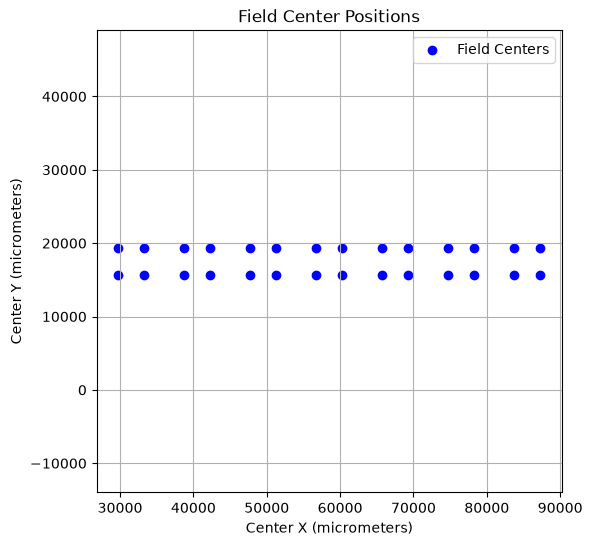

In [53]:
if sample.scene_count:
    for s in range(sample.scene_count):
        well_name = sample.well_array_names[s] or "<missing>"
        region_id = sample.well_region_ids[s]
        center_x = sample.field_centerX[s]
        center_y = sample.field_centerY[s]

    # plot all cneter XY positions as a simple grid
    plt.figure(figsize=(6, 6))
    plt.scatter(sample.field_centerX, sample.field_centerY, marker="o", color="blue", label="Field Centers")
    plt.title("Field Center Positions")
    plt.xlabel("Center X (micrometers)")
    plt.ylabel("Center Y (micrometers)")
    plt.grid()
    plt.axis('equal')
    plt.legend()
    plt.show()  

The model retains the original CZI well indices as well as normalized
zero-based indices. Field indices are local to a well; scene indices are global
to the CZI.

Resolver functions map selectors to the model without reading pixels:

In [38]:
from czitools.metadata_tools.hcs import resolve_field, resolve_well

well = resolve_well(plate, "B/04")
field = resolve_field(plate, "B/04", 0)

print(f"Field Region ID: {field.region_id}")

# A source RegionId string can select the same field.
if field.region_id is not None:
    same_field = resolve_field(plate, "B04", field.region_id)

print("------------------------------------------")

# show some parameters of the field
print(f"Field Region ID: {same_field.id}")
print(f"Position Name: {same_field.position_name}")
print(f"Field Index: {same_field.field_index}")


Field Region ID: 637232309317131710
------------------------------------------
Field Region ID: field:637232309317131710
Position Name: P1
Field Index: 0


The compatibility-oriented `mdata.sample` object exposes per-scene
collections.

Prefer `sample.field_centerX` and `sample.field_centerY`: they
preserve valid `0.0` coordinates and use `None` for missing positions.

The
deprecated `scene_stageX` and `scene_stageY` properties convert missing values
to `0.0`.

HCS detection is an additional interpretation. If `mdata.hcs` is `None`,
general metadata and ordinary CZI pixel reading remain available.

### Optional stage-position enrichment

Scene-center positions come from scene XML. Subblock stage/focus coordinates
can be added explicitly from the planetable for a local CZI:

In [39]:
enriched_plate = mdata.enrich_hcs_positions(position_tolerance=1.0)

if enriched_plate is not None:
    well = enriched_plate.get_well("B04")
    for field in well.fields:
        print(
            f"Field StageX: {field.stage_x}",
            f"Field StageY: {field.stage_y}",
            f"Acquisition Z: {field.acquisition_z}",
            f"Position Conflict: {field.position_conflict}",
        )

  0% |                                                  | ETA:  --:--:-- 0 of 28
100% |#################################################| Time:  0:00:00 28 of 28


Field StageX: 29687.5 Field StageY: 15687.5 Acquisition Z: 111.842 Position Conflict: False
Field StageX: 33312.5 Field StageY: 15687.5 Acquisition Z: 111.842 Position Conflict: False
Field StageX: 29687.5 Field StageY: 19312.5 Acquisition Z: 111.842 Position Conflict: False
Field StageX: 33312.5 Field StageY: 19312.5 Acquisition Z: 111.842 Position Conflict: False


> Important: Enrichment returns a new immutable plate and updates `mdata.hcs`.
> It keeps scene-center and subblock-stage coordinates separate and is unavailable for URL
> sources.

Position helpers expose well-relative scene-center offsets and absolute
coordinates. They return `None` if any required coordinate is missing:

In [ ]:
from czitools.metadata_tools.hcs import (
    well_absolute_field_positions,
    well_relative_field_positions,
)

if enriched_plate is None:
    raise ValueError("Stage positions are unavailable.")

well = enriched_plate.get_well("B04")
relative = well_relative_field_positions(well)
scene_centers = well_absolute_field_positions(well, source="scene_center")
stage_positions = well_absolute_field_positions(well, source="stage")

# show all well attributes
for parameter in well.__dict__:
    print(f"{parameter}: {getattr(well, parameter)}")

print("---------   Show individual field parameter   ------------")

for fp in well.fields[0].__dict__:
    print(f"{fp}: {getattr(well.fields[0], fp)}")


id: well:B4
canonical_name: B4
canonical_path: B/4
source_name: B4
source_row_index: 2
source_column_index: 4
row_index: 1
column_index: 3
external_id: None
fields: (CziField(id='field:637232309317131710', field_index=0, scene_index=0, region_id='637232309317131710', position_name='P1', scene_center_x=29687.5, scene_center_y=15687.5, position_unit='micrometer', position_source='Scene.CenterPosition', acquisition_z=111.842, stage_x=29687.5, stage_y=15687.5, stage_x_range=(29687.5, 29687.5), stage_y_range=(15687.5, 15687.5), acquisition_z_range=(111.842, 111.842), stage_unit='micrometer', stage_source='planetable(StageXPosition,StageYPosition,FocusPosition)', subblock_count=1, position_conflict=False), CziField(id='field:637232309317131711', field_index=1, scene_index=1, region_id='637232309317131711', position_name='P2', scene_center_x=33312.5, scene_center_y=15687.5, position_unit='micrometer', position_source='Scene.CenterPosition', acquisition_z=111.842, stage_x=33312.5, stage_y=1568

## Reading by Well / Field (HCS Plates)

For high-content-screening plates, wells and fields can be read directly by name
without tracking scene indices. These reads use the canonical HCS model
(`CziMetadata.hcs`) and reuse the single-scene read path.

In [58]:
from czitools.read_tools import read_field, read_well

# Read a single field of a well (well names accept "B4", "b04" or "B/4").
# `field` is the well-local 0-based index, or a source-scoped RegionId string.
array, mdata = read_field(filepath, well="B4", field=0)

# Read all fields of a well as a list of per-field arrays (shapes may differ).
arrays, mdata = read_well(filepath, well="B4")

# Stack the fields along the S axis (requires identical field shapes).
stacked, mdata = read_well(filepath, well="B4", stack=True)

2026-07-31 15:00:21,367 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-31 15:00:21,658 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-31 15:00:21,748 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


...

  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-31 15:00:22,325 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


2026-07-31 15:00:22,553 - czitools - INFO - read_6darray: Reading 1 planes (S=1, T=1, C=1, Z=1)


  0% |                                                   | ETA:  --:--:-- 0 of 1
100% |###################################################| Time:  0:00:00 1 of 1


In [ ]:
# get_well normalizes capitalization and zero padding, so B04 resolves to B4.
print(f"\nFields in requested well {selected_well!r} -> {well.canonical_name}:")
for field in well.fields:
    print(
        f"  local={field.field_index} scene={field.scene_index} id={field.id} "
        f"region={field.region_id} center=({field.scene_center_x}, {field.scene_center_y}) "
        f"{field.position_unit}"
        )